### **Tarea semanal 0:Primeros pasos en la simulación**

#### Autor: Gerónimo García

#### Consigna

En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal (volts)
su valor medio (volts)
la frecuencia (Hz)
la fase (radianes)
la cantidad de muestras digitalizada por el ADC (# muestras)
la frecuencia de muestreo del ADC.
es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)
Recuerden que tanto xx como tt deben ser vectores de Nx1. Puede resultarte útil el módulo de visualización matplotlib.pyplot donde encontrarán todas las funciones de visualización estilo Matlab. Para usarlo:

import matplotlib.pyplot as plt
plt.plot(tt, xx)
Entrega
Recuerden que solo tienen que entregar una URL a su notebook. Con esa URL ya tendré acceso a su repositorio y todo lo que usaron.

https://nbviewer.jupyter.org/github/marianux/PDS/blob/main/preparacion.ipynb


Bonus:

💎 Ser el primero en subir un enlace a tu notebook en esta tarea
Realizar los experimentos que se comentaron en clase. Siguiendo la notación de la función definida más arriba:
ff = 500 Hz
ff = 999 Hz
ff = 1001 Hz
ff = 2001 Hz
🤯 Implementar alguna otra señal propia de un generador de señales. 
Ayudas:
La función numpy.sin seguro te va a servir.
No hace falta usar ningún lazo de control for, while, etc.
Podés consultar en el chat cualquier duda o problema que vayas encontrando. Buena suerte!

In [2]:
# Importo las librerias que necesito

import numpy as np
import matplotlib.pyplot as plt

En esta primera parte se definio un vector tiempo (tt) que genera n muestras espaciadas de forma 
uniforme entre 0 y n-1. Además, se definio la señal xx de forma tal que genere una señal senoidal.

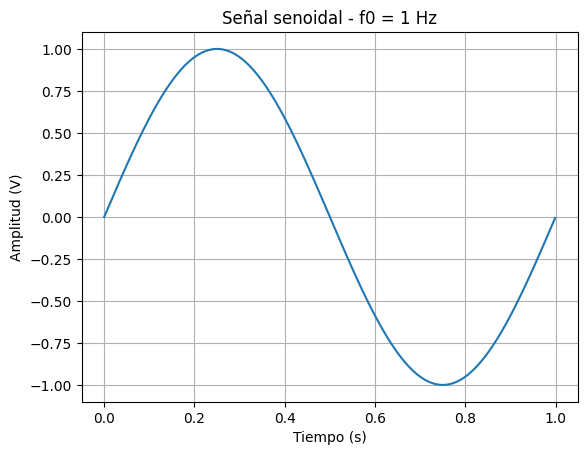

In [3]:
#%%
fs = 1000 #Hz, frecuencia de muestreo

f0 = 1 #Hz, frecuencia de la senoidal

n=1000 # muestras por ciclo

vmax=1 #volt

dc=0 #valor medio, volts

ts = 1 / fs #ts es el periodo de muestreo. Indica el tiempo entre muestra y muestra.

def mi_funcion_sen(vmax, dc, f0,n, fs, ph=0):
    tt=np.linspace(0, (n-1)*ts,n)
    xx=dc+vmax*np.sin(2*np.pi*f0*tt+ph)
    
    return tt,xx

tt,xx = mi_funcion_sen(vmax, dc, f0,n, fs, ph=0)
plt.title(f'Señal senoidal - f0 = {f0} Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.plot(tt, xx)

En este bloque se le agrego a la señal ruido gaussiano de media mu=0 y desvío estandar sigma=1.
De esta forma se busca simular el ruido que apareceria en cualquier medición real. 

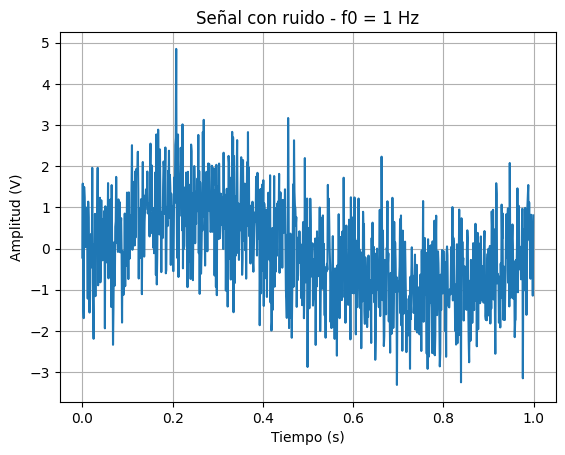

In [5]:
#%%Señal con ruido
sigma=1
mu=0
U_n=np.random.normal(mu,sigma,n)
xxn=xx+U_n
plt.figure()
plt.plot(tt, xxn)
plt.title(f'Señal con ruido - f0 = {f0} Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)

Con los casos que se analizan a continuación de tomando frecuencias de 500Hz, 999Hz, 1001HZ
y 2001 Hz se busca analizar que pasa con la señal cuando nos encontramos exactamente en la frecuencia de Nyquist 
(fs/2) y que sucede con los valores mayores a esta frecuencia.

En este primer caso nos encontramos exactamente en la frecuencia de nyquist. 

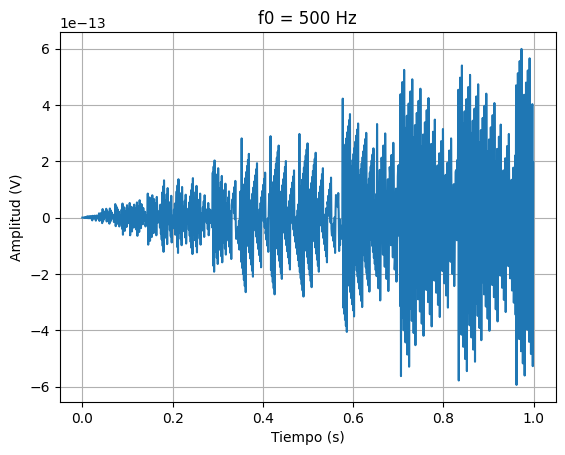

In [6]:
#%% f0=500 Hz
f0 = 500
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.plot(tt, xx)
plt.title('f0 = 500 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)


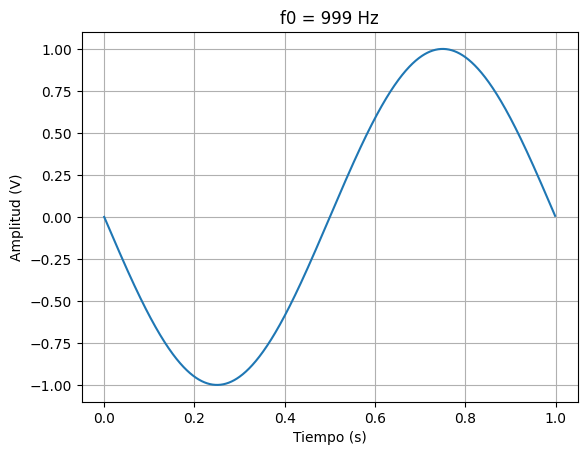

In [7]:
#%% f0=999 Hz
f0 = 999
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.plot(tt, xx)
plt.title('f0 = 999 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)

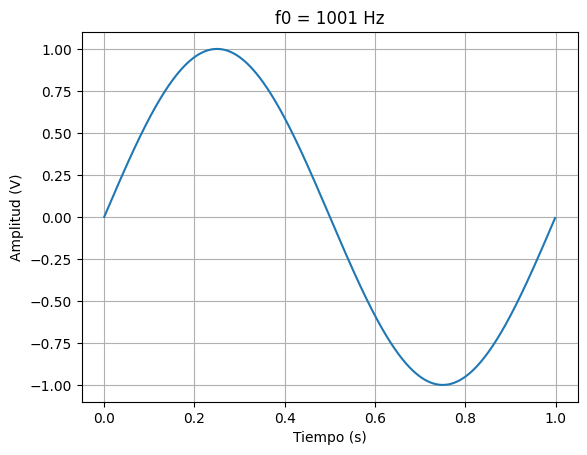

In [8]:
#%% f0=1001 Hz
f0 = 1001
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.plot(tt, xx)
plt.title('f0 = 1001 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)


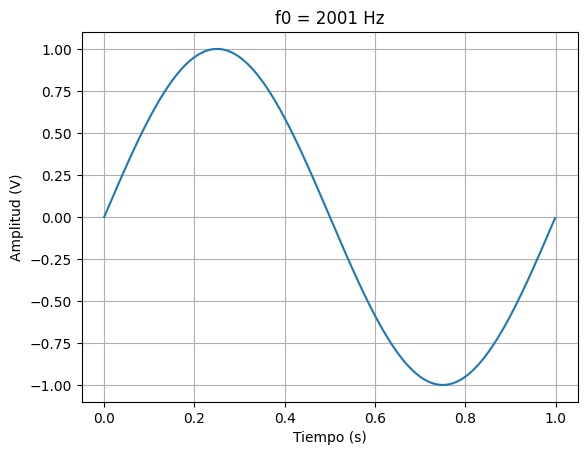

In [9]:
#%% f0=2001 Hz
f0 = 2001
tt, xx = mi_funcion_sen(vmax, dc, f0, n, fs, ph=0)
plt.figure()
plt.plot(tt, xx)
plt.title('f0 = 2001 Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)


En los casos de frecuencia 1001 Hz y 2001 Hz se observa la misma grafica ya que al ser una funcion periodica al recorrer todas las muestras vuelve a 
comenzar y muestra lo mismo.

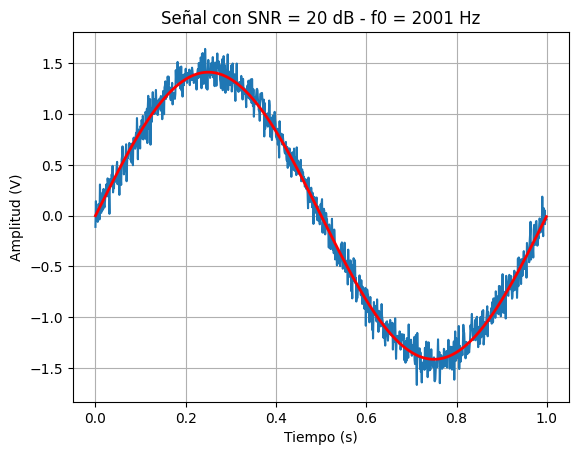

In [10]:
#%% Potencia de señal
vmax=np.sqrt(2)
tt,xx=mi_funcion_sen(vmax, dc, f0,n, fs, ph=0)
Px=np.var(xx)
SNR=20
Pr=10**(-SNR/10) #para llegar al resultado hay que usar log.
U_n = np.random.normal(mu,np.sqrt(Pr),n)

xxn=xx+U_n

plt.figure(1)
plt.clf()
plt.plot(tt, xxn)
plt.plot(tt, xx, 'r', lw=2)
plt.title(f'Señal con SNR = {SNR} dB - f0 = {f0} Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)

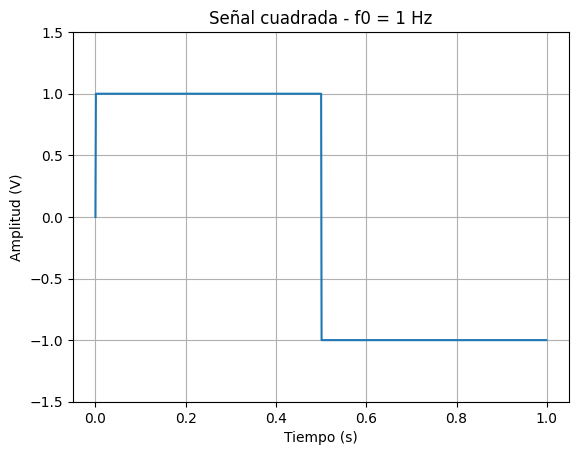

In [11]:
#%% Señal cuadrada

def mi_funcion_cuadrada(vmax, dc, f0, n, fs, duty=0.5, ph=0):
    ts = 1 / fs
    tt = np.linspace(0, (n-1)*ts, n)
    xx = dc + vmax * np.sign(np.sin(2*np.pi*f0*tt + ph))
    return tt, xx

f0 = 1       # Hz
tt, xx = mi_funcion_cuadrada(vmax=1, dc=0, f0=f0, n=1000, fs=1000)

plt.figure()
plt.title(f'Señal cuadrada - f0 = {f0} Hz')
plt.plot(tt, xx)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.show()